# 04 Explainability
Using Temporal Importance (Occlusion) to determine the most relevant signal parts.

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (parent / 'src').exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


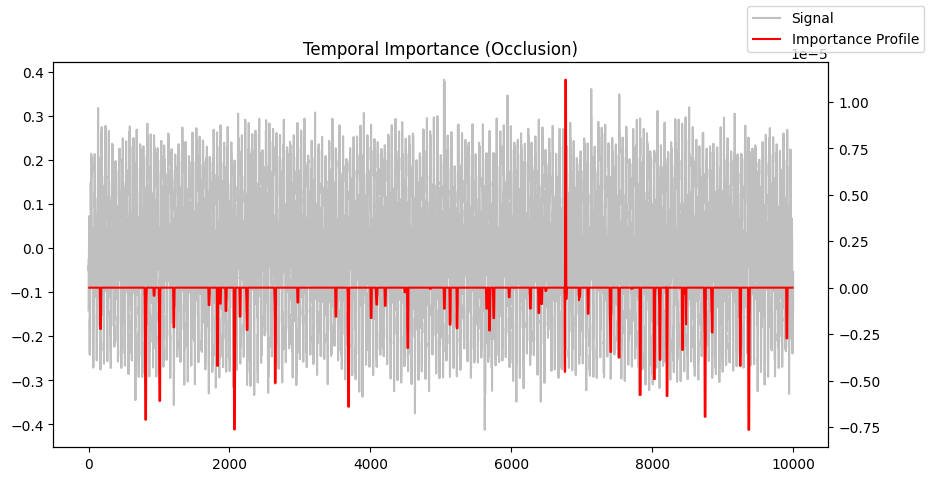

In [4]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from src.config import MODELS_DIR, SYNTHETIC_DATA_DIR
from src.explainability.temporal_importance import compute_temporal_importance

with open(MODELS_DIR / 'sktime_mlp_classifier.pkl', 'rb') as f:
    clf = pickle.load(f)

events = np.load(SYNTHETIC_DATA_DIR / 'event_samples.npy')
signal = events[0]

scores, pos = compute_temporal_importance(clf, signal)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(signal, color='gray', alpha=0.5, label='Signal')
ax2 = ax1.twinx()
ax2.plot(pos, scores, color='red', label='Importance Profile')
fig.legend(loc='upper right')
plt.title('Temporal Importance (Occlusion)')
plt.show()